# 📊 Training Your First Ensemble Model

## 🎯 Objective
Now that you’ve explored multiple ensemble learning methods, your task is to **train and interpret a full ensemble model** using either **Random Forest** or **XGBoost**.

This assignment focuses on:
- Making an informed modeling choice
- Understanding how ensembles improve predictions
- Not just maximizing accuracy

---

## 🧾 Assignment Instructions

### ✅ Load Your Gold Dataset
- Load your `additional_files/customer_churn_gold.csv` file.
- Confirm:
  - No null values
  - Feature and target shapes are correct
- Split into:
  - `X` (features)
  - `y = Churn`
- Store your results in variable `X` and `y`

---

In [1]:
import pandas as pd
import numpy as np 

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

In [2]:
# YOUR CODE HERE
df = pd.read_csv('additional_files/customer_churn_gold.csv')

In [3]:
df.isnull().sum().sum()

0

In [4]:
df.head()

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,MonthlyCharges,TotalCharges,TotalCharges_scaled,tenure_scaled,MonthlyCharges_scaled,Churn_encoded,PaymentMethod_encoded,tenure_years,long_contract,StreamingServices
0,0,5375.0,0.0,0,1.0,0.0,1,0.0,1.0,0.0,...,29.85,29.85,-0.992611,-1.277445,-1.160323,0.0,0.0,0.083333,0,0.0
1,1,3962.0,1.0,0,0.0,0.0,34,1.0,0.0,0.0,...,56.95,1889.50,-0.172165,0.066327,-0.259629,0.0,1.0,2.833333,1,0.0
2,2,2564.0,1.0,0,0.0,0.0,2,1.0,0.0,0.0,...,53.85,108.15,-0.958066,-1.236724,-0.362660,1.0,1.0,0.166667,0,0.0
3,3,5535.0,1.0,0,0.0,0.0,45,0.0,1.0,0.0,...,42.30,1840.75,-0.193672,0.514251,-0.746535,0.0,2.0,3.750000,1,0.0
4,4,6511.0,0.0,0,0.0,0.0,2,1.0,0.0,1.0,...,70.70,151.65,-0.938874,-1.236724,0.197365,1.0,0.0,0.166667,0,0.0


In [5]:
df = df.iloc[:,1:]

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customerID             7043 non-null   float64
 1   gender                 7043 non-null   float64
 2   SeniorCitizen          7043 non-null   int64  
 3   Partner                7043 non-null   float64
 4   Dependents             7043 non-null   float64
 5   tenure                 7043 non-null   int64  
 6   PhoneService           7043 non-null   float64
 7   MultipleLines          7043 non-null   float64
 8   InternetService        7043 non-null   float64
 9   OnlineSecurity         7043 non-null   float64
 10  OnlineBackup           7043 non-null   float64
 11  DeviceProtection       7043 non-null   float64
 12  TechSupport            7043 non-null   float64
 13  StreamingTV            7043 non-null   float64
 14  StreamingMovies        7043 non-null   float64
 15  Cont

In [7]:
df['Churn_encoded'] = df['Churn_encoded'].astype('int64')

There are no null values in the dataset, all categorical variables are encoded and features are engineered.


In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'MonthlyCharges', 'TotalCharges', 'TotalCharges_scaled',
       'tenure_scaled', 'MonthlyCharges_scaled', 'Churn_encoded',
       'PaymentMethod_encoded', 'tenure_years', 'long_contract',
       'StreamingServices'],
      dtype='object')

In [9]:
X = df[ [col for col in df.columns if col != 'Churn_encoded'] ]
X.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,MonthlyCharges,TotalCharges,TotalCharges_scaled,tenure_scaled,MonthlyCharges_scaled,PaymentMethod_encoded,tenure_years,long_contract,StreamingServices
0,5375.0,0.0,0,1.0,0.0,1,0.0,1.0,0.0,0.0,...,1.0,29.85,29.85,-0.992611,-1.277445,-1.160323,0.0,0.083333,0,0.0
1,3962.0,1.0,0,0.0,0.0,34,1.0,0.0,0.0,2.0,...,0.0,56.95,1889.50,-0.172165,0.066327,-0.259629,1.0,2.833333,1,0.0
2,2564.0,1.0,0,0.0,0.0,2,1.0,0.0,0.0,2.0,...,1.0,53.85,108.15,-0.958066,-1.236724,-0.362660,1.0,0.166667,0,0.0
3,5535.0,1.0,0,0.0,0.0,45,0.0,1.0,0.0,2.0,...,0.0,42.30,1840.75,-0.193672,0.514251,-0.746535,2.0,3.750000,1,0.0
4,6511.0,0.0,0,0.0,0.0,2,1.0,0.0,1.0,0.0,...,1.0,70.70,151.65,-0.938874,-1.236724,0.197365,0.0,0.166667,0,0.0


In [10]:
y = df['Churn_encoded']
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn_encoded, dtype: int64

---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    
 -  Make sure to save your answer in the variable named `X`, `y` respectively.
 -  If these variable are not found, you answer will be rejected by the system

## 📂 Loading your data

- Clean and transform your data.
    - Drop the `customerID` column
    - Convert `TotalCharges` to numeric (handles spaces or non-numeric values)
    - Convert target column `y` to binary values
    - Identify column types
    - Convert relevant columns using one hot encoding and fill in any missing values using `SimpleImputer`

Store your clean data into a variable named `X_cleaned`.
Your X_cleaned should be a numpy array that looks like this 

```python
([[  0.  ,   1.  ,  29.85, ...,   0.  ,   1.  ,   0.  ],
       [  0.  ,  34.  ,  56.95, ...,   0.  ,   0.  ,   1.  ],
       [  0.  ,   2.  ,  53.85, ...,   0.  ,   0.  ,   1.  ],
```

Hint :- Your `X_cleaned `should have an approximate shape of (7043, 45)

Overall, 
- Recreate the **features** and **target** used in your ensemble model from your `X` & `y`

In [11]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

#### I had already converted the dataset into gold in Module 3 and am using the same. So, there is no need to do much data preprocessing ####


In [12]:
# YOUR CODE HERE
X_cleaned = X.iloc[:,1:].to_numpy() #Dropping the customer ID column
X_cleaned


array([[0.        , 0.        , 1.        , ..., 0.08333333, 0.        ,
        0.        ],
       [1.        , 0.        , 0.        , ..., 2.83333333, 1.        ,
        0.        ],
       [1.        , 0.        , 0.        , ..., 0.16666667, 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 1.        , ..., 0.91666667, 0.        ,
        0.        ],
       [1.        , 1.        , 1.        , ..., 0.33333333, 0.        ,
        0.        ],
       [1.        , 0.        , 0.        , ..., 5.5       , 1.        ,
        4.        ]])

In [13]:
X_cleaned.shape

(7043, 25)

---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    
 -  Make sure to save your answer in the variable named `X_cleaned` respectively.
 -  If these variable are not found, you answer will be rejected by the system

## 📂 Splitting your data
Now that we have cleaned our data. 
- Time to split our data into train and test sets,
- Go for a 75/25 split or anything near that. 
- Store your answer in the variable named `X_train`, `X_test`, `y_train`, `y_test` respectively

In [14]:
from sklearn.model_selection import train_test_split

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

In [15]:
X_cleaned.shape

(7043, 25)

In [16]:
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y, test_size = 0.25, stratify = y)

---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    
 -  Make sure to save your answer in the variable named `X_train`, `X_test`, `y_train`, `y_test` respectively.
 -  If these variable are not found, you answer will be rejected by the system

### 🤖 Choose One Ensemble Model

Select one model from this module:

- `RandomForestClassifier` from `sklearn`
- `XGBClassifier` from `xgboost`

Both are valid — but you **must justify your choice**.

---

# ✍️ **Write (2–4 sentences):**
- Why did you choose this model?
- How does it handle the bias-variance tradeoff?
- What strengths make it suitable for this classification task?

## Make sure to write the answer below this cell

I am choosing RandomForestClassifier for model training.

- This model is relatively easier to train, faster and requires minimal parameter tuning.
- RandomForest is a bagging Ensemble model, which reduces overfitting and hence reducing variance. The number of trees decides how general the prediction will be. 
- We get good performance without much hyperparameter tuning, works best on small-medium datasets.

### 🏋️‍♀️ Train Your Model

- Now that we have our `X_train`, `X_test`, `y_train` & `y_test`. We can start training our models
- Fit your model on the training set
- Store your model in a variable named `model`
---

In [26]:
pip install xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 1.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 2.3 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.1.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [17]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

In [18]:
# YOUR CODE HERE
model = RandomForestClassifier()

In [19]:
model.fit(X_train, y_train)

RandomForestClassifier()

In [20]:
model

RandomForestClassifier()

---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    
 -  Make sure to save your answer in the variable named `model` respectively.
 -  If these variable are not found, you answer will be rejected by the system

### 🔮 Evaluation

- Store your predictions for the training data in a variable named `train_preds`.
- Store your predictions for the testing data in a variable named `test_preds`.
- Evaluate `accuracy_score` for both train and test sets
    - Store your `accuracy` for the training data in a variable named `training_acc`.
    - Store your `accuracy` for the testing data in a variable named `testing_acc`.


In [21]:
from sklearn.metrics import accuracy_score

In [22]:
# YOUR CODE HERE
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)


In [23]:
training_acc = accuracy_score(train_pred, y_train)

In [24]:
test_acc = accuracy_score(test_pred, y_test)

In [26]:
print('Accuracy of Training data: ', training_acc)
print('Accuracy of Testing data: ', test_acc)

Accuracy of Training data:  0.9981067777357062
Accuracy of Testing data:  0.7978421351504826


---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    
 -  Make sure to save your answer in the variable named `train_preds`, `test_preds`, `training_acc` & `testing_acc` respectively.
 -  If these variable are not found, you answer will be rejected by the system

# ✍️ **Write (brief):**
- What are your train and test accuracies?
- Is overfitting a concern?
- How well does the model generalize?


## Make sure to write the answer below this cell

- The training accuracy is 99.8%, while the testing accuracy is 79%.
- Yes! The model has highly overfitted the data with high variance.
- As, the testing accuracy is 79%, while the training is close to 100%, we can clearly say that the model is overfitting.

### 🔍 Interpret the Model

Use built-in model tools:

#### For **Random Forest**:
- Use `.feature_importances_`
- Optionally, visualize one tree using `plot_tree`

#### For **XGBoost**:
- Use `plot_importance()` and/or `plot_tree()`
---

In [25]:
# Check if Random Forest was used
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd

In [26]:
# YOUR CODE HERE
model.feature_importances_


array([0.02084388, 0.01695213, 0.01762443, 0.01395444, 0.06938679,
       0.00334086, 0.0159403 , 0.01689994, 0.03504175, 0.01493739,
       0.01519625, 0.03243223, 0.00916758, 0.00913466, 0.05691513,
       0.0205995 , 0.10788169, 0.09992295, 0.09641963, 0.0790362 ,
       0.11002033, 0.04308658, 0.06827149, 0.01226713, 0.01472676])

In [27]:
X.iloc[:,1:].columns[model.feature_importances_.argmax()]

'MonthlyCharges_scaled'

In [28]:
from sklearn.tree import plot_tree

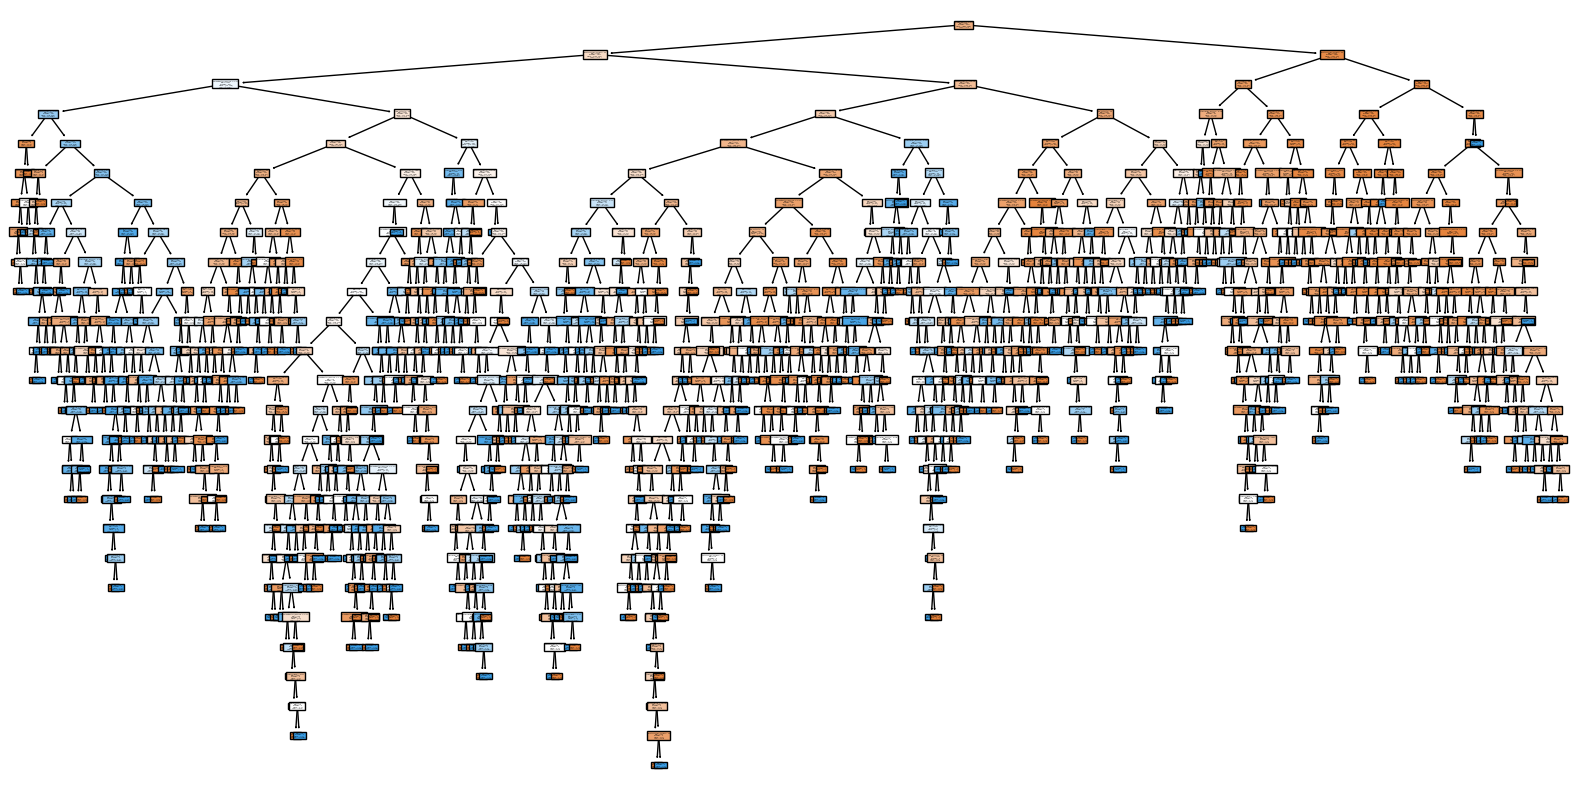

In [29]:
estimator = model.estimators_[0]

plt.figure(figsize=(20, 10))  
plot_tree(estimator,
          filled=True,
          feature_names= X.columns,  
          class_names=["Churn", "No Churn"])  # churn vs no churn
plt.savefig('RandomForest.png')
plt.show()

---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    

# ✍️ **Write (3–5 sentences):**
- Which features are most important?
- Does this match your intuition or expectations?
- What does the model seem to “pay attention to”?


## Make sure to write the answer below this cell

- Monthly_Charges is the most important feature
- Ya, it does make sense that if monthly charges are less, the customer is quite likely to give importance to the recurring bill and remains with the company.
- The graph is really very dense. So much so that its unable to render properly in a png image 😅. The depth is also about 10-15! This might be the for overfitting and the model is paying attention to the training data too much.

### 🧪 Optional: Tune One Hyperparameter

Try modifying **one** of the following:
- `max_depth`
- `learning_rate`
- `n_estimators`

---

In [30]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

In [47]:
# YOUR CODE HERE
model = RandomForestClassifier(max_depth = 8)

In [48]:
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8)

In [49]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

In [50]:
print('Accuracy of Training: ', accuracy_score(train_pred, y_train))
print('Accuracy of Testing: ', accuracy_score(test_pred, y_test))

Accuracy of Training:  0.8498674744414995
Accuracy of Testing:  0.7938671209540034


---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    

# ✍️ **Write (1–2 sentences):**
- What did you change?
- Did performance improve?


## Make sure to write the answer below this cell

- Seeing the overfitting problem which is generally caused due to deep trees, I changed the max_depth to 8.
- The overfitting problem got solved, but the accuracy of the test data didn't improve.

### 🔍 Optional: Sample Prediction Bonus

- Pick one sample from your test set
- Use `.predict()` or `.predict_proba()` to explain the prediction
- Describe how the model handled this case

---

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    

# ✍️ **Write (short paragraph):**
- What decision did the model make?
- Which features most likely influenced the result?

## Make sure to write the answer below this cell

YOUR ANSWER HERE

## ✅ Deliverables Checklist

Your notebook should include:

- ✅ Code to load, train, and evaluate your model
- ✅ Model summary and interpretation (with visuals or explanations)
- ✅ Written insights for:
  - Model selection
  - Training results
  - Feature importance
  - Optional tuning
  - (Optional) Sample prediction

---

---

<h2><center> Completing your test </center></h2>

- Once you have completed your test and answered all the questions:
  
- You can open the guide using the button located on the far right of your screen.

- The button will look like this image:  
  ![](additional_files/End_guide_button.png)

- Clicking on this button will allow you to mark the test as complete using the button shown below:  
  ![](additional_files/completion_button.png)

- Please click on **Mark as Completed** to end and submit your test.

- Thank you!
